<a href="https://colab.research.google.com/github/abdullahminhas/cric-squad-selector/blob/main/cric_squad_selector_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building our player-match dataset from Cricsheet.
Tests, ODIs, and T20Is — one CSV each, committed to GitHub as we go.

In [44]:
# connect to GitHub repo
from google.colab import userdata
import os

GH_TOKEN = userdata.get('GH_TOKEN')
REPO_URL = f"https://{GH_TOKEN}@github.com/abdullahminhas/cric-squad-selector.git"

if not os.path.exists('cric-squad-selector'):
    !git clone {REPO_URL}

%cd cric-squad-selector
!git config user.email "aminhas1996@gmail.com"
!git config user.name "abdullahminhas"
os.makedirs('data', exist_ok=True)

print(os.getcwd())

Cloning into 'cric-squad-selector'...
remote: Enumerating objects: 7086, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 7086 (delta 12), reused 0 (delta 0), pack-reused 7065 (from 2)
Receiving objects: 100% (7086/7086), 122.08 MiB | 19.60 MiB/s, done.
Resolving deltas: 100% (6906/6906), done.
/content/cric-squad-selector/cric-squad-selector
/content/cric-squad-selector/cric-squad-selector


The function below downloads a Cricsheet zip, unzips it, and turns every match into player-level rows.
We check the download/unzip actually worked, so it fails loudly instead of silently.

In [45]:
# parser function
import json, pandas as pd

def build_player_match_dataset(zip_url, extract_folder):
    zip_name = extract_folder + ".zip"

    exit_code = os.system(f'wget -q --user-agent="Mozilla/5.0" {zip_url} -O {zip_name}')
    if exit_code != 0 or not os.path.exists(zip_name) or os.path.getsize(zip_name) == 0:
        raise RuntimeError(f"Download failed for {zip_url}")

    exit_code = os.system(f"unzip -q -o {zip_name} -d {extract_folder}")
    if exit_code != 0 or not os.path.exists(extract_folder):
        raise RuntimeError(f"Unzip failed for {zip_name}")

    all_rows = []

    for file in os.listdir(extract_folder):
        if not file.endswith(".json"):
            continue

        with open(os.path.join(extract_folder, file)) as f:
            data = json.load(f)

        info = data["info"]
        match_id = file.replace(".json", "")
        date = info["dates"][0]
        fmt = info.get("match_type")
        venue = info.get("venue")
        teams = info["teams"]
        winner = info["outcome"].get("winner")
        pom_list = info.get("player_of_match", [])
        registry = info.get("registry", {}).get("people", {})

        players_stats = {}
        for team, plist in info.get("players", {}).items():
            opp = teams[1] if team == teams[0] else teams[0]
            for p in plist:
                players_stats[p] = {
                    "match_id": match_id, "player_id": registry.get(p), "player_name": p,
                    "team": team, "opposition": opp, "date": date, "format": fmt, "venue": venue,
                    "batting_position": None, "runs": 0, "balls_faced": 0, "fours": 0, "sixes": 0,
                    "dismissal_type": None, "dismissed": False,
                    "balls_bowled": 0, "maidens": 0, "runs_conceded": 0, "wickets": 0,
                    "wides": 0, "no_balls": 0, "dot_balls": 0, "fours_conceded": 0, "sixes_conceded": 0,
                    "catches": 0, "run_outs": 0, "stumpings": 0,
                    "team_won": (winner == team) if winner else None,
                    "player_of_match": p in pom_list,
                }

        for innings in data.get("innings", []):
            bat_position_counter = [0]
            seen_batters = set()

            for over in innings.get("overs", []):
                over_runs_total = 0
                over_bowler = None

                for ball in over.get("deliveries", []):
                    batter = ball["batter"]
                    bowler = ball["bowler"]
                    over_bowler = bowler
                    runs = ball["runs"]
                    extras = ball.get("extras", {})
                    total_runs = runs["total"]
                    over_runs_total += total_runs

                    if batter not in seen_batters:
                        seen_batters.add(batter)
                        bat_position_counter[0] += 1
                        if batter in players_stats:
                            players_stats[batter]["batting_position"] = bat_position_counter[0]

                    if batter in players_stats:
                        players_stats[batter]["balls_faced"] += 1
                        players_stats[batter]["runs"] += runs["batter"]
                        if runs["batter"] == 4:
                            players_stats[batter]["fours"] += 1
                        if runs["batter"] == 6:
                            players_stats[batter]["sixes"] += 1

                    if bowler in players_stats:
                        is_legal_ball = "wides" not in extras and "noballs" not in extras
                        if is_legal_ball:
                            players_stats[bowler]["balls_bowled"] += 1
                        byes_legbyes = extras.get("byes", 0) + extras.get("legbyes", 0)
                        players_stats[bowler]["runs_conceded"] += (total_runs - byes_legbyes)
                        players_stats[bowler]["wides"] += extras.get("wides", 0)
                        players_stats[bowler]["no_balls"] += extras.get("noballs", 0)
                        if total_runs == 0:
                            players_stats[bowler]["dot_balls"] += 1
                        if runs["batter"] == 4:
                            players_stats[bowler]["fours_conceded"] += 1
                        if runs["batter"] == 6:
                            players_stats[bowler]["sixes_conceded"] += 1

                    if "wickets" in ball:
                        for w in ball["wickets"]:
                            out_player = w["player_out"]
                            kind = w["kind"]

                            if out_player in players_stats:
                                players_stats[out_player]["dismissed"] = True
                                players_stats[out_player]["dismissal_type"] = kind

                            if bowler in players_stats and kind != "run out":
                                players_stats[bowler]["wickets"] += 1

                            fielders = [flr.get("name") for flr in w.get("fielders", []) if flr.get("name")]
                            for flr in fielders:
                                if flr not in players_stats:
                                    continue
                                if kind == "caught":
                                    players_stats[flr]["catches"] += 1
                                elif kind == "stumped":
                                    players_stats[flr]["stumpings"] += 1
                                elif kind == "run out":
                                    players_stats[flr]["run_outs"] += 1

                if over_bowler in players_stats and over_runs_total == 0:
                    players_stats[over_bowler]["maidens"] += 1

        all_rows.extend(players_stats.values())

    return pd.DataFrame(all_rows)

Test matches
Downloads Test data, builds the CSV, and shows a quick preview.

In [46]:
tests_df = build_player_match_dataset(
    "https://cricsheet.org/downloads/tests_male_json.zip", "tests_data"
)
tests_df.to_csv("data/test_player_match.csv", index=False)
print(tests_df.shape)
tests_df.head()

(19604, 29)


,match_id,player_id,player_name,team,opposition,date,format,venue,batting_position,runs,...,wides,no_balls,dot_balls,fours_conceded,sixes_conceded,catches,run_outs,stumpings,team_won,player_of_match
0,690347,3b041a12,Tamim Iqbal,Bangladesh,Sri Lanka,2014-01-27,Test,Shere Bangla National Stadium,1.0,17,...,0,0,0,0,0,0,0,0,False,False
1,690347,02789d88,Shamsur Rahman,Bangladesh,Sri Lanka,2014-01-27,Test,Shere Bangla National Stadium,2.0,42,...,0,0,0,0,0,0,0,0,False,False
2,690347,e72d8f6a,Marshall Ayub,Bangladesh,Sri Lanka,2014-01-27,Test,Shere Bangla National Stadium,3.0,19,...,0,0,21,3,0,1,0,0,False,False
3,690347,de0a3209,Mominul Haque,Bangladesh,Sri Lanka,2014-01-27,Test,Shere Bangla National Stadium,4.0,58,...,0,0,23,2,0,0,0,0,False,False
4,690347,7dc35884,Shakib Al Hasan,Bangladesh,Sri Lanka,2014-01-27,Test,Shere Bangla National Stadium,5.0,80,...,0,0,177,12,6,0,0,0,False,False


In [47]:
import pandas as pd

df = pd.read_csv("data/test_player_match.csv")

summary = df.groupby(["player_id", "player_name"]).agg(
    format=("format", "first"),
    matches=("match_id", "nunique"),
    innings_batted=("balls_faced", lambda x: (x > 0).sum()),
    runs=("runs", "sum"),
    balls_faced=("balls_faced", "sum"),
    fours=("fours", "sum"),
    sixes=("sixes", "sum"),
    times_out=("dismissed", "sum"),
    innings_bowled=("balls_bowled", lambda x: (x > 0).sum()),
    balls_bowled=("balls_bowled", "sum"),
    runs_conceded=("runs_conceded", "sum"),
    wickets=("wickets", "sum"),
    maidens=("maidens", "sum"),
    catches=("catches", "sum"),
    run_outs=("run_outs", "sum"),
    stumpings=("stumpings", "sum"),
    player_of_match_count=("player_of_match", "sum"),
).reset_index()

# calculated fields
summary["batting_avg"] = (summary["runs"] / summary["times_out"].replace(0, pd.NA)).round(2)
summary["strike_rate"] = (summary["runs"] / summary["balls_faced"].replace(0, pd.NA) * 100).round(2)
summary["bowling_avg"] = (summary["runs_conceded"] / summary["wickets"].replace(0, pd.NA)).round(2)
summary["economy"] = (summary["runs_conceded"] / (summary["balls_bowled"].replace(0, pd.NA) / 6)).round(2)

summary.to_csv("data/test_player_summary.csv", index=False)
print(summary.shape)
summary.head()

(1066, 23)


,player_id,player_name,format,matches,innings_batted,runs,balls_faced,fours,sixes,times_out,...,wickets,maidens,catches,run_outs,stumpings,player_of_match_count,batting_avg,strike_rate,bowling_avg,economy
0,004c9e85,PJ Hughes,Test,26,26,1535,2871,199,11,26,...,0,0,15,0,0,1,59.038462,53.465691,<NA>,<NA>
1,00ea847a,MA Agarwal,Test,21,21,1488,2786,190,28,21,...,0,0,14,0,0,2,70.857143,53.409907,<NA>,<NA>
2,00ea9791,HP Tillakaratne,Test,2,2,70,180,9,0,2,...,0,0,0,0,0,0,35.0,38.888889,<NA>,<NA>
3,012829ff,JW Hastings,Test,1,1,52,89,5,2,1,...,1,3,1,0,0,0,52.0,58.426966,153.0,3.923077
4,0164b064,MG Neser,Test,5,5,131,258,19,1,5,...,22,21,1,0,0,0,26.2,50.775194,18.909091,3.208226


ODI


In [48]:
odis_df = build_player_match_dataset(
    "https://cricsheet.org/downloads/odis_male_json.zip", "odis_data"
)
odis_df.to_csv("data/odi_player_match.csv", index=False)
print(odis_df.shape)
odis_df.head()

(56628, 29)


,match_id,player_id,player_name,team,opposition,date,format,venue,batting_position,runs,...,wides,no_balls,dot_balls,fours_conceded,sixes_conceded,catches,run_outs,stumpings,team_won,player_of_match
0,1294969,df7ed601,T Kaitano,Zimbabwe,Sri Lanka,2022-01-16,ODI,Pallekele International Cricket Stadium,1.0,42,...,0,0,0,0,0,0,0,0,False,False
1,1294969,2f0d7e4a,RW Chakabva,Zimbabwe,Sri Lanka,2022-01-16,ODI,Pallekele International Cricket Stadium,2.0,72,...,0,0,0,0,0,2,0,0,False,False
2,1294969,c96311d4,CR Ervine,Zimbabwe,Sri Lanka,2022-01-16,ODI,Pallekele International Cricket Stadium,3.0,9,...,0,0,0,0,0,1,0,0,False,False
3,1294969,afe57f7a,SC Williams,Zimbabwe,Sri Lanka,2022-01-16,ODI,Pallekele International Cricket Stadium,4.0,100,...,0,0,19,2,1,0,0,0,False,False
4,1294969,a879b92c,W Madhevere,Zimbabwe,Sri Lanka,2022-01-16,ODI,Pallekele International Cricket Stadium,5.0,20,...,0,0,3,1,1,0,0,0,False,False


In [49]:
df = pd.read_csv("data/odi_player_match.csv")

summary = df.groupby(["player_id", "player_name"]).agg(
    format=("format", "first"),
    matches=("match_id", "nunique"),
    innings_batted=("balls_faced", lambda x: (x > 0).sum()),
    runs=("runs", "sum"),
    balls_faced=("balls_faced", "sum"),
    fours=("fours", "sum"),
    sixes=("sixes", "sum"),
    times_out=("dismissed", "sum"),
    innings_bowled=("balls_bowled", lambda x: (x > 0).sum()),
    balls_bowled=("balls_bowled", "sum"),
    runs_conceded=("runs_conceded", "sum"),
    wickets=("wickets", "sum"),
    maidens=("maidens", "sum"),
    catches=("catches", "sum"),
    run_outs=("run_outs", "sum"),
    stumpings=("stumpings", "sum"),
    player_of_match_count=("player_of_match", "sum"),
).reset_index()

summary["batting_avg"] = (summary["runs"] / summary["times_out"].replace(0, pd.NA)).round(2)
summary["strike_rate"] = (summary["runs"] / summary["balls_faced"].replace(0, pd.NA) * 100).round(2)
summary["bowling_avg"] = (summary["runs_conceded"] / summary["wickets"].replace(0, pd.NA)).round(2)
summary["economy"] = (summary["runs_conceded"] / (summary["balls_bowled"].replace(0, pd.NA) / 6)).round(2)

summary.to_csv("data/odi_player_summary.csv", index=False)
print(summary.shape)
summary.head()

(1993, 23)


,player_id,player_name,format,matches,innings_batted,runs,balls_faced,fours,sixes,times_out,...,wickets,maidens,catches,run_outs,stumpings,player_of_match_count,batting_avg,strike_rate,bowling_avg,economy
0,004c9e85,PJ Hughes,ODI,25,24,826,1118,91,5,23,...,0,0,5,1,0,2,35.913043,73.881932,<NA>,<NA>
1,008589a4,CM Wright,ODI,7,6,81,145,4,1,5,...,8,9,1,0,0,0,16.2,55.862069,28.5,4.470588
2,00d69fa4,SO Tikolo,ODI,39,38,705,1097,75,6,35,...,26,6,16,0,0,0,20.142857,64.26618,34.692308,5.062675
3,00ea847a,MA Agarwal,ODI,5,5,86,91,12,1,5,...,0,0,2,0,0,0,17.2,94.505495,<NA>,10.0
4,00ea9791,HP Tillakaratne,ODI,16,13,332,562,28,0,11,...,0,0,10,0,0,0,30.181818,59.074733,<NA>,<NA>


T20

In [50]:
t20is_df = build_player_match_dataset(
    "https://cricsheet.org/downloads/t20s_male_json.zip", "t20is_data"
)
t20is_df.to_csv("data/t20i_player_match.csv", index=False)
print(t20is_df.shape)
t20is_df.head()

(77580, 29)


,match_id,player_id,player_name,team,opposition,date,format,venue,batting_position,runs,...,wides,no_balls,dot_balls,fours_conceded,sixes_conceded,catches,run_outs,stumpings,team_won,player_of_match
0,1486224,5338b9f5,Muhammad Muneeb,Belgium,Portugal,2025-06-01,T20,"Stars Arena Hofstade, Zemst",1.0,15,...,0,0,0,0,0,0,0,0,True,False
1,1486224,838bc6ab,A Raza,Belgium,Portugal,2025-06-01,T20,"Stars Arena Hofstade, Zemst",2.0,64,...,0,0,0,0,0,3,0,0,True,False
2,1486224,b7824537,B Niaz,Belgium,Portugal,2025-06-01,T20,"Stars Arena Hofstade, Zemst",3.0,35,...,0,0,0,0,0,0,0,0,True,False
3,1486224,b6bad765,Shaheryar Butt,Belgium,Portugal,2025-06-01,T20,"Stars Arena Hofstade, Zemst",4.0,21,...,0,0,0,0,0,0,0,0,True,False
4,1486224,036dcf9b,Saber Zakhil,Belgium,Portugal,2025-06-01,T20,"Stars Arena Hofstade, Zemst",5.0,4,...,0,0,3,4,1,0,0,0,True,False


In [51]:
df = pd.read_csv("data/t20i_player_match.csv")

summary = df.groupby(["player_id", "player_name"]).agg(
    format=("format", "first"),
    matches=("match_id", "nunique"),
    innings_batted=("balls_faced", lambda x: (x > 0).sum()),
    runs=("runs", "sum"),
    balls_faced=("balls_faced", "sum"),
    fours=("fours", "sum"),
    sixes=("sixes", "sum"),
    times_out=("dismissed", "sum"),
    innings_bowled=("balls_bowled", lambda x: (x > 0).sum()),
    balls_bowled=("balls_bowled", "sum"),
    runs_conceded=("runs_conceded", "sum"),
    wickets=("wickets", "sum"),
    maidens=("maidens", "sum"),
    catches=("catches", "sum"),
    run_outs=("run_outs", "sum"),
    stumpings=("stumpings", "sum"),
    player_of_match_count=("player_of_match", "sum"),
).reset_index()

summary["batting_avg"] = (summary["runs"] / summary["times_out"].replace(0, pd.NA)).round(2)
summary["strike_rate"] = (summary["runs"] / summary["balls_faced"].replace(0, pd.NA) * 100).round(2)
summary["bowling_avg"] = (summary["runs_conceded"] / summary["wickets"].replace(0, pd.NA)).round(2)
summary["economy"] = (summary["runs_conceded"] / (summary["balls_bowled"].replace(0, pd.NA) / 6)).round(2)

summary.to_csv("data/t20i_player_summary.csv", index=False)
print(summary.shape)
summary.head()

(4741, 23)


,player_id,player_name,format,matches,innings_batted,runs,balls_faced,fours,sixes,times_out,...,wickets,maidens,catches,run_outs,stumpings,player_of_match_count,batting_avg,strike_rate,bowling_avg,economy
0,00029c30,M Mwamadi,T20,6,3,5,11,0,0,0,...,3,0,0,0,0,0,<NA>,45.454545,25.333333,7.354839
1,00075cb5,MCE Manalo,T20,1,1,12,16,0,0,1,...,0,0,0,0,0,0,12.0,75.0,<NA>,<NA>
2,000803b1,Het Patel,T20,2,1,1,9,0,0,0,...,0,0,1,0,0,0,<NA>,11.111111,<NA>,<NA>
3,00321fff,Mohammad Ghazanfar,T20,34,13,41,64,3,0,6,...,34,2,5,0,0,2,6.833333,64.0625,20.294118,6.854305
4,00467a76,S Bodha,T20,34,12,77,79,7,1,8,...,37,0,6,0,0,1,9.625,97.468354,22.810811,8.496644


Master CSV

In [52]:
import pandas as pd

tests_df = pd.read_csv("data/test_player_match.csv")
odis_df = pd.read_csv("data/odi_player_match.csv")
t20is_df = pd.read_csv("data/t20i_player_match.csv")

master_match = pd.concat([tests_df, odis_df, t20is_df], ignore_index=True)
master_match.to_csv("data/master_player_match.csv", index=False)

print(master_match.shape)



(153812, 29)


**Feature engineering:**
Turning raw match stats into rolling form features the model can actually use.

Sort by player and date, so rolling stats are calculated in the right order.

In [53]:
df = pd.read_csv("data/master_player_match.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)

print(df.shape)
df.head()

(153812, 29)


,match_id,player_id,player_name,team,opposition,date,format,venue,batting_position,runs,...,wides,no_balls,dot_balls,fours_conceded,sixes_conceded,catches,run_outs,stumpings,team_won,player_of_match
0,1283024,00029c30,M Mwamadi,Malawi,Uganda,2021-10-16,T20,Integrated Polytechnic Regional Centre,9.0,0,...,0,0,0,0,0,0,0,0,False,False
1,1283026,00029c30,M Mwamadi,Malawi,Swaziland,2021-10-17,T20,Integrated Polytechnic Regional Centre,NaN,0,...,1,0,5,0,0,0,0,0,True,False
2,1283029,00029c30,M Mwamadi,Malawi,Ghana,2021-10-19,T20,Gahanga International Cricket Stadium. Rwanda,9.0,3,...,0,0,1,1,2,0,0,0,False,False
3,1283033,00029c30,M Mwamadi,Malawi,Seychelles,2021-10-20,T20,Gahanga International Cricket Stadium. Rwanda,NaN,0,...,0,0,4,0,1,0,0,0,True,False
4,1283040,00029c30,M Mwamadi,Malawi,Rwanda,2021-10-22,T20,Gahanga International Cricket Stadium. Rwanda,4.0,2,...,3,0,12,0,2,0,0,0,True,False


Rolling batting form — average runs and strike rate over the last 5 and last 10 matches.

In [54]:
#step 2
def add_rolling_batting_features(df, window):
    grouped = df.groupby("player_id")

    df[f"runs_last{window}"] = grouped["runs"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    )
    df[f"balls_faced_last{window}"] = grouped["balls_faced"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).sum()
    )
    runs_sum = grouped["runs"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).sum()
    )
    df[f"strike_rate_last{window}"] = (runs_sum / df[f"balls_faced_last{window}"] * 100).round(2)

    return df

df = add_rolling_batting_features(df, 5)
df = add_rolling_batting_features(df, 10)

df[["player_name", "date", "runs", "runs_last5", "strike_rate_last5", "runs_last10", "strike_rate_last10"]].head(15)
df.to_csv("data/master_player_match_features.csv", index=False)

Rolling bowling form — average wickets and economy over the last 5 and last 10 matches.

In [55]:
def add_rolling_bowling_features(df, window):
    grouped = df.groupby("player_id")

    df[f"wickets_last{window}"] = grouped["wickets"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    )
    balls_bowled_sum = grouped["balls_bowled"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).sum()
    )
    runs_conceded_sum = grouped["runs_conceded"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).sum()
    )
    df[f"economy_last{window}"] = (runs_conceded_sum / (balls_bowled_sum / 6)).round(2)

    return df

df = add_rolling_bowling_features(df, 5)
df = add_rolling_bowling_features(df, 10)

df[["player_name", "date", "wickets", "wickets_last5", "economy_last5", "wickets_last10", "economy_last10"]].head(15)

,player_name,date,wickets,wickets_last5,economy_last5,wickets_last10,economy_last10
0,M Mwamadi,2021-10-16,0,NaN,NaN,NaN,NaN
1,M Mwamadi,2021-10-17,1,0.000000,NaN,0.000000,NaN
2,M Mwamadi,2021-10-19,0,0.500000,3.00,0.500000,3.00
3,M Mwamadi,2021-10-20,0,0.333333,8.70,0.333333,8.70
4,M Mwamadi,2021-10-22,2,0.250000,7.74,0.250000,7.74
5,M Mwamadi,2022-09-20,0,0.600000,7.35,0.600000,7.35
6,MCE Manalo,2025-07-09,0,NaN,NaN,NaN,NaN
7,Het Patel,2026-03-24,0,NaN,NaN,NaN,NaN
8,Het Patel,2026-03-25,0,0.000000,NaN,0.000000,NaN
9,Mohammad Ghazanfar,2019-10-06,0,NaN,NaN,NaN,NaN


Rolling fielding form average catches, run-outs, and stumpings over the last 5 and last 10 matches.

In [13]:
def add_rolling_fielding_features(df, window):
    grouped = df.groupby("player_id")

    df[f"catches_last{window}"] = grouped["catches"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    ).round(2)
    df[f"run_outs_last{window}"] = grouped["run_outs"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    ).round(2)
    df[f"stumpings_last{window}"] = grouped["stumpings"].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    ).round(2)

    return df

df = add_rolling_fielding_features(df, 5)
df = add_rolling_fielding_features(df, 10)

df[["player_name", "date", "catches", "catches_last5", "run_outs_last5", "stumpings_last5"]].head(15)
df.to_csv("data/master_player_match_features.csv", index=False)

Career-to-date stats: batting average, strike rate, bowling average, and economy calculated only from matches before this one.


In [14]:
def add_career_to_date_features(df):
    grouped = df.groupby("player_id")

    runs_cum = grouped["runs"].transform(lambda x: x.shift(1).expanding().sum())
    balls_faced_cum = grouped["balls_faced"].transform(lambda x: x.shift(1).expanding().sum())
    times_out_cum = grouped["dismissed"].transform(lambda x: x.shift(1).expanding().sum())

    wickets_cum = grouped["wickets"].transform(lambda x: x.shift(1).expanding().sum())
    balls_bowled_cum = grouped["balls_bowled"].transform(lambda x: x.shift(1).expanding().sum())
    runs_conceded_cum = grouped["runs_conceded"].transform(lambda x: x.shift(1).expanding().sum())

    df["career_batting_avg"] = (runs_cum / times_out_cum.replace(0, pd.NA)).round(2)
    df["career_strike_rate"] = (runs_cum / balls_faced_cum.replace(0, pd.NA) * 100).round(2)
    df["career_bowling_avg"] = (runs_conceded_cum / wickets_cum.replace(0, pd.NA)).round(2)
    df["career_economy"] = (runs_conceded_cum / (balls_bowled_cum.replace(0, pd.NA) / 6)).round(2)
    df["career_matches_played"] = grouped.cumcount()

    return df

df = add_career_to_date_features(df)

df[["player_name", "date", "runs", "career_batting_avg", "career_strike_rate", "career_bowling_avg", "career_economy", "career_matches_played"]].head(15)

,player_name,date,runs,career_batting_avg,career_strike_rate,career_bowling_avg,career_economy,career_matches_played
0,M Mwamadi,2021-10-16,0,NaN,NaN,NaN,NaN,0
1,M Mwamadi,2021-10-17,0,<NA>,0.0,<NA>,<NA>,1
2,M Mwamadi,2021-10-19,3,<NA>,0.0,4.0,3.0,2
3,M Mwamadi,2021-10-20,0,<NA>,37.5,29.0,8.7,3
4,M Mwamadi,2021-10-22,2,<NA>,37.5,49.0,7.736842,4
5,M Mwamadi,2022-09-20,0,<NA>,45.454545,25.333333,7.354839,5
6,MCE Manalo,2025-07-09,12,NaN,NaN,NaN,NaN,0
7,Het Patel,2026-03-24,0,NaN,NaN,NaN,NaN,0
8,Het Patel,2026-03-25,1,<NA>,<NA>,<NA>,<NA>,1
9,Mohammad Ghazanfar,2019-10-06,0,NaN,NaN,NaN,NaN,0


Opposition-specific form how this player has performed against this exact opposition team, based only on past matches against them.

In [15]:
def add_opposition_form_features(df):
    grouped = df.groupby(["player_id", "opposition"])

    runs_cum = grouped["runs"].transform(lambda x: x.shift(1).expanding().sum())
    balls_faced_cum = grouped["balls_faced"].transform(lambda x: x.shift(1).expanding().sum())
    times_out_cum = grouped["dismissed"].transform(lambda x: x.shift(1).expanding().sum())

    wickets_cum = grouped["wickets"].transform(lambda x: x.shift(1).expanding().sum())
    balls_bowled_cum = grouped["balls_bowled"].transform(lambda x: x.shift(1).expanding().sum())
    runs_conceded_cum = grouped["runs_conceded"].transform(lambda x: x.shift(1).expanding().sum())

    df["avg_vs_opposition"] = (runs_cum / times_out_cum.replace(0, pd.NA)).round(2)
    df["strike_rate_vs_opposition"] = (runs_cum / balls_faced_cum.replace(0, pd.NA) * 100).round(2)
    df["bowling_avg_vs_opposition"] = (runs_conceded_cum / wickets_cum.replace(0, pd.NA)).round(2)
    df["economy_vs_opposition"] = (runs_conceded_cum / (balls_bowled_cum.replace(0, pd.NA) / 6)).round(2)
    df["matches_vs_opposition"] = grouped.cumcount()

    return df

df = add_opposition_form_features(df)

df[["player_name", "date", "opposition", "runs", "avg_vs_opposition", "matches_vs_opposition"]].head(15)
df.to_csv("data/master_player_match_features.csv", index=False)

Venue-specific form — how this player has performed at this exact ground, based only on past matches there.

In [16]:
def add_venue_form_features(df):
    grouped = df.groupby(["player_id", "venue"])

    runs_cum = grouped["runs"].transform(lambda x: x.shift(1).expanding().sum())
    balls_faced_cum = grouped["balls_faced"].transform(lambda x: x.shift(1).expanding().sum())
    times_out_cum = grouped["dismissed"].transform(lambda x: x.shift(1).expanding().sum())
    wickets_cum = grouped["wickets"].transform(lambda x: x.shift(1).expanding().sum())
    balls_bowled_cum = grouped["balls_bowled"].transform(lambda x: x.shift(1).expanding().sum())
    runs_conceded_cum = grouped["runs_conceded"].transform(lambda x: x.shift(1).expanding().sum())

    df["avg_at_venue"] = (runs_cum / times_out_cum.replace(0, pd.NA)).round(2)
    df["strike_rate_at_venue"] = (runs_cum / balls_faced_cum.replace(0, pd.NA) * 100).round(2)
    df["bowling_avg_at_venue"] = (runs_conceded_cum / wickets_cum.replace(0, pd.NA)).round(2)
    df["economy_at_venue"] = (runs_conceded_cum / (balls_bowled_cum.replace(0, pd.NA) / 6)).round(2)
    df["matches_at_venue"] = grouped.cumcount()

    return df

df = add_venue_form_features(df)
df[["player_name", "date", "venue", "runs", "avg_at_venue", "matches_at_venue"]].head(15)

,player_name,date,venue,runs,avg_at_venue,matches_at_venue
0,M Mwamadi,2021-10-16,Integrated Polytechnic Regional Centre,0,NaN,0
1,M Mwamadi,2021-10-17,Integrated Polytechnic Regional Centre,0,<NA>,1
2,M Mwamadi,2021-10-19,Gahanga International Cricket Stadium. Rwanda,3,NaN,0
3,M Mwamadi,2021-10-20,Gahanga International Cricket Stadium. Rwanda,0,<NA>,1
4,M Mwamadi,2021-10-22,Gahanga International Cricket Stadium. Rwanda,2,<NA>,2
5,M Mwamadi,2022-09-20,"Willowmoore Park, Benoni",0,NaN,0
6,MCE Manalo,2025-07-09,Udayana Cricket Ground,12,NaN,0
7,Het Patel,2026-03-24,"Achimota Senior Secondary School A Field, Accra",0,NaN,0
8,Het Patel,2026-03-25,"Achimota Senior Secondary School B Field, Accra",1,NaN,0
9,Mohammad Ghazanfar,2019-10-06,Al Amerat Cricket Ground Oman Cricket (Ministr...,0,NaN,0


Fill missing values from early-career matches, where no prior history exists yet.

In [17]:
rolling_cols = [c for c in df.columns if any(c.startswith(p) for p in [
    "runs_last", "balls_faced_last", "strike_rate_last",
    "wickets_last", "economy_last", "catches_last", "run_outs_last", "stumpings_last",
    "career_", "avg_vs_opposition", "strike_rate_vs_opposition", "bowling_avg_vs_opposition", "economy_vs_opposition",
    "avg_at_venue", "strike_rate_at_venue", "bowling_avg_at_venue", "economy_at_venue"
])]

df[rolling_cols] = df[rolling_cols].fillna(0)

print(df[rolling_cols].isnull().sum().sum(), "missing values remaining")

/tmp/ipykernel_2495/3630346680.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[rolling_cols] = df[rolling_cols].fillna(0)


0 missing values remaining


Define the target: did this player play in their team's next international match?

In [18]:
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)

df["next_match_date"] = df.groupby("player_id")["date"].shift(-1)
df["days_to_next_match"] = (df["next_match_date"] - df["date"]).dt.days

# played again within a reasonable selection window (e.g. next 180 days)
df["played_next_match"] = (df["days_to_next_match"] <= 180).astype(int)
df.loc[df["next_match_date"].isna(), "played_next_match"] = pd.NA

df[["player_name", "date", "next_match_date", "days_to_next_match", "played_next_match"]].head(15)

,player_name,date,next_match_date,days_to_next_match,played_next_match
0,M Mwamadi,2021-10-16,2021-10-17,1.0,1.0
1,M Mwamadi,2021-10-17,2021-10-19,2.0,1.0
2,M Mwamadi,2021-10-19,2021-10-20,1.0,1.0
3,M Mwamadi,2021-10-20,2021-10-22,2.0,1.0
4,M Mwamadi,2021-10-22,2022-09-20,333.0,0.0
5,M Mwamadi,2022-09-20,NaT,NaN,NaN
6,MCE Manalo,2025-07-09,NaT,NaN,NaN
7,Het Patel,2026-03-24,2026-03-25,1.0,1.0
8,Het Patel,2026-03-25,NaT,NaN,NaN
9,Mohammad Ghazanfar,2019-10-06,2019-10-07,1.0,1.0


In [19]:
df.to_csv("data/master_player_match_features.csv", index=False)

Final assembly drop rows with no target (last match per player), and save the model-ready dataset.

In [20]:
model_ready_df = df[df["played_next_match"].notna()].copy()
model_ready_df["played_next_match"] = model_ready_df["played_next_match"].astype(int)

model_ready_df = model_ready_df.drop(columns=["next_match_date", "days_to_next_match"])

model_ready_df.to_csv("data/model_ready_dataset.csv", index=False)

print(model_ready_df.shape)
model_ready_df["played_next_match"].value_counts()
from google.colab import files
files.download("data/model_ready_dataset.csv")

(148378, 61)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Preparing the dataset for training:** selecting features, encoding categories, and splitting by date.

Load the model-ready dataset and separate identifier columns from actual model features.

In [21]:
import pandas as pd

df = pd.read_csv("data/model_ready_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

# columns that identify the row, not used as model input
id_cols = ["match_id", "player_id", "player_name", "date", "venue"]

# the actual target
target_col = "played_next_match"

# raw match-outcome columns (what happened IN this match) - excluded, these are not "form" indicators
raw_match_cols = ["runs", "balls_faced", "fours", "sixes", "dismissed", "dismissal_type",
                   "balls_bowled", "maidens", "runs_conceded", "wickets", "wides", "no_balls",
                   "dot_balls", "fours_conceded", "sixes_conceded", "catches", "run_outs",
                   "stumpings", "player_of_match", "team_won", "batting_position"]

feature_cols = [c for c in df.columns if c not in id_cols + [target_col] + raw_match_cols]
print(len(feature_cols), "feature columns selected")
print(feature_cols)

34 feature columns selected
['team', 'opposition', 'format', 'runs_last5', 'balls_faced_last5', 'strike_rate_last5', 'runs_last10', 'balls_faced_last10', 'strike_rate_last10', 'wickets_last5', 'economy_last5', 'wickets_last10', 'economy_last10', 'catches_last5', 'run_outs_last5', 'stumpings_last5', 'catches_last10', 'run_outs_last10', 'stumpings_last10', 'career_batting_avg', 'career_strike_rate', 'career_bowling_avg', 'career_economy', 'career_matches_played', 'avg_vs_opposition', 'strike_rate_vs_opposition', 'bowling_avg_vs_opposition', 'economy_vs_opposition', 'matches_vs_opposition', 'avg_at_venue', 'strike_rate_at_venue', 'bowling_avg_at_venue', 'economy_at_venue', 'matches_at_venue']


Encode team, opposition, and format as numbers, since models can't use raw text.

In [22]:
categorical_cols = ["team", "opposition", "format"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# update feature list to include the new encoded columns
encoded_feature_cols = [c for c in df_encoded.columns if c not in id_cols + [target_col] + raw_match_cols]
print(len(encoded_feature_cols), "feature columns after encoding")

252 feature columns after encoding


Split by date instead of randomly, so the model is tested only on matches after the training period.

In [23]:
split_date = df_encoded["date"].quantile(0.8)
print("Split date:", split_date)

train_df = df_encoded[df_encoded["date"] < split_date]
test_df = df_encoded[df_encoded["date"] >= split_date]

X_train = train_df[encoded_feature_cols]
y_train = train_df[target_col]
X_test = test_df[encoded_feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Split date: 2024-09-07 00:00:00
Train shape: (118677, 252)
Test shape: (29701, 252)


Check class balance in both sets, and confirm no missing values remain before training.

In [24]:
print("Train target balance:")
print(y_train.value_counts(normalize=True))

print("\nTest target balance:")
print(y_test.value_counts(normalize=True))

print("\nMissing values in features:", X_train.isnull().sum().sum())

Train target balance:
played_next_match
1    0.940603
0    0.059397
Name: proportion, dtype: float64

Test target balance:
played_next_match
1    0.96256
0    0.03744
Name: proportion, dtype: float64

Missing values in features: 0


Training a plain Random Forest first, to see what happens without addressing class imbalance.

Train a baseline Random Forest with default settings.

In [25]:
# from sklearn.ensemble import RandomForestClassifier

# baseline_model = RandomForestClassifier(random_state=42)
# baseline_model.fit(X_train, y_train)

# y_pred_baseline = baseline_model.predict(X_test)
# print("Baseline model trained.")

Fix — clean infinities before training

In [26]:
import numpy as np

# check how many infinite values exist
inf_count = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
print("Infinite values in X_train:", inf_count)

# replace inf/-inf with 0 (same treatment as our earlier missing-value strategy)
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

print("Infinite values after cleaning:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

Infinite values in X_train: 4
Infinite values after cleaning: 0


In [27]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
print("Baseline model trained.")

Baseline model trained.


Evaluate the baseline model, look beyond accuracy.

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("\nClassification report:\n", classification_report(y_test, y_pred_baseline))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_baseline))

Accuracy: 0.9619204740581125

Classification report:
               precision    recall  f1-score   support

           0       0.15      0.00      0.01      1112
           1       0.96      1.00      0.98     28589

    accuracy                           0.96     29701
   macro avg       0.56      0.50      0.49     29701
weighted avg       0.93      0.96      0.94     29701

Confusion matrix:
 [[    4  1108]
 [   23 28566]]


Retrain with class weighting, so the model is penalized more for missing the minority class.

In [29]:
from sklearn.ensemble import RandomForestClassifier

balanced_model = RandomForestClassifier(random_state=42, class_weight="balanced")
balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification report:\n", classification_report(y_test, y_pred_balanced))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_balanced))

Accuracy: 0.9575098481532608

Classification report:
               precision    recall  f1-score   support

           0       0.05      0.01      0.01      1112
           1       0.96      0.99      0.98     28589

    accuracy                           0.96     29701
   macro avg       0.51      0.50      0.50     29701
weighted avg       0.93      0.96      0.94     29701

Confusion matrix:
 [[    9  1103]
 [  159 28430]]


Class weighting alone wasn't enough — try oversampling the minority class with SMOTE instead.

In [30]:
!pip install -q imbalanced-learn

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {1: 111628, 0: 7049}
After SMOTE: {1: 111628, 0: 111628}


Retrain Random Forest on the SMOTE-balanced training data.

In [32]:
smote_model = RandomForestClassifier(random_state=42)
smote_model.fit(X_train_resampled, y_train_resampled)

y_pred_smote = smote_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nClassification report:\n", classification_report(y_test, y_pred_smote))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_smote))

Accuracy: 0.9374768526312245

Classification report:
               precision    recall  f1-score   support

           0       0.08      0.06      0.07      1112
           1       0.96      0.97      0.97     28589

    accuracy                           0.94     29701
   macro avg       0.52      0.52      0.52     29701
weighted avg       0.93      0.94      0.93     29701

Confusion matrix:
 [[   68  1044]
 [  813 27776]]


Check feature importance to see what the model is actually relying on.

In [33]:
import pandas as pd

importances = pd.Series(smote_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(20))

career_matches_played        0.058001
catches_last5                0.047284
format_T20                   0.042673
run_outs_last10              0.037433
balls_faced_last10           0.037048
matches_vs_opposition        0.035751
catches_last10               0.033209
run_outs_last5               0.033088
career_batting_avg           0.032118
balls_faced_last5            0.027579
runs_last10                  0.027514
career_strike_rate           0.024219
strike_rate_last5            0.022725
strike_rate_last10           0.022600
runs_last5                   0.021875
avg_vs_opposition            0.021322
career_economy               0.020693
strike_rate_vs_opposition    0.020537
career_bowling_avg           0.020531
economy_last10               0.019631
dtype: float64


Visualize the top features.

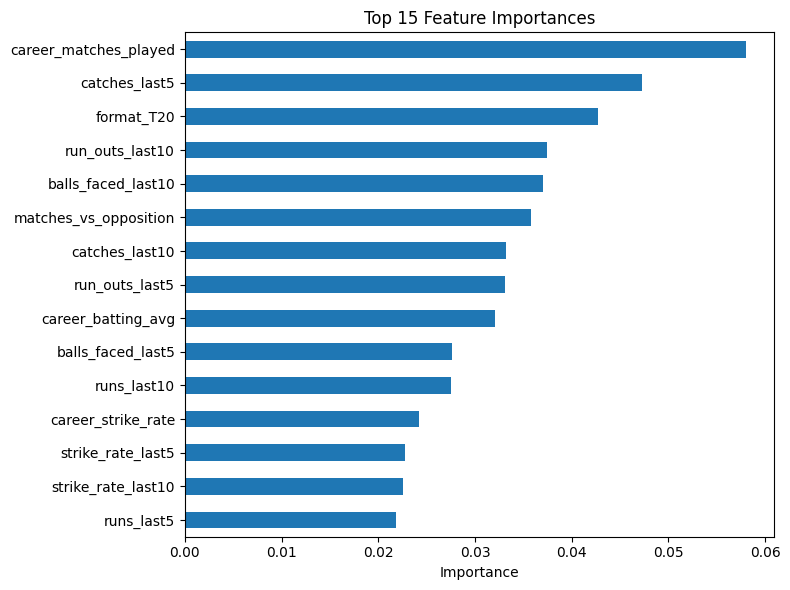

In [34]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

Testing format-specific models — since format_T20 ranked highly, check if separate models per format perform better.

Split the dataset by format, keeping the same train/test date split.

In [35]:
formats = df_encoded["format"].unique() if "format" in df_encoded.columns else None

# format was one-hot encoded earlier, so recover it from the original df
train_formats = train_df.merge(df[["match_id", "player_id", "format"]], on=["match_id", "player_id"], how="left")
test_formats = test_df.merge(df[["match_id", "player_id", "format"]], on=["match_id", "player_id"], how="left")

print(train_formats["format"].value_counts())
print(test_formats["format"].value_counts())

format
ODI     51084
T20     50085
Test    17508
Name: count, dtype: int64
format
T20     23582
ODI      4583
Test     1536
Name: count, dtype: int64


Train and evaluate a separate model for each format.

In [36]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

for fmt in train_formats["format"].dropna().unique():
    print(f"\n===== {fmt} =====")

    train_mask = train_formats["format"] == fmt
    test_mask = test_formats["format"] == fmt

    X_train_fmt = X_train[train_mask.values]
    y_train_fmt = y_train[train_mask.values]
    X_test_fmt = X_test[test_mask.values]
    y_test_fmt = y_test[test_mask.values]

    if y_train_fmt.nunique() < 2 or len(X_test_fmt) == 0:
        print("Not enough data for this format, skipping.")
        continue

    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_train_fmt, y_train_fmt)

    model_fmt = RandomForestClassifier(random_state=42)
    model_fmt.fit(X_res, y_res)

    y_pred_fmt = model_fmt.predict(X_test_fmt)

    print("Accuracy:", accuracy_score(y_test_fmt, y_pred_fmt))
    print(classification_report(y_test_fmt, y_pred_fmt))


===== T20 =====
Accuracy: 0.9403358493766432
              precision    recall  f1-score   support

           0       0.09      0.05      0.07       949
           1       0.96      0.98      0.97     22633

    accuracy                           0.94     23582
   macro avg       0.53      0.52      0.52     23582
weighted avg       0.93      0.94      0.93     23582


===== Test =====
Accuracy: 0.94921875
              precision    recall  f1-score   support

           0       0.14      0.05      0.07        63
           1       0.96      0.99      0.97      1473

    accuracy                           0.95      1536
   macro avg       0.55      0.52      0.52      1536
weighted avg       0.93      0.95      0.94      1536


===== ODI =====
Accuracy: 0.9755618590442942
              precision    recall  f1-score   support

           0       0.12      0.02      0.03       100
           1       0.98      1.00      0.99      4483

    accuracy                           0.98      45

Reframe as a regression problem: predict runs in the player's next match instead of yes/no selection.

In [37]:
df = df.sort_values(["player_id", "date"]).reset_index(drop=True)
df["next_match_runs"] = df.groupby("player_id")["runs"].shift(-1)

regression_df = df[df["next_match_runs"].notna()].copy()
print(regression_df.shape)
regression_df[["player_name", "date", "runs", "next_match_runs"]].head(10)

(143414, 62)


,player_name,date,runs,next_match_runs
0,M Mwamadi,2021-10-16,0,0.0
1,M Mwamadi,2021-10-17,0,3.0
2,M Mwamadi,2021-10-19,3,0.0
3,M Mwamadi,2021-10-20,0,2.0
6,Mohammad Ghazanfar,2019-10-06,0,4.0
7,Mohammad Ghazanfar,2019-10-07,4,0.0
8,Mohammad Ghazanfar,2019-10-10,0,0.0
9,Mohammad Ghazanfar,2019-10-27,0,6.0
10,Mohammad Ghazanfar,2019-10-30,6,2.0
11,Mohammad Ghazanfar,2022-07-11,2,0.0


Train/test split and train a Random Forest Regressor.

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

regression_df_encoded = pd.get_dummies(regression_df, columns=["team", "opposition", "format"], drop_first=True)
reg_feature_cols = [c for c in regression_df_encoded.columns if c not in id_cols + raw_match_cols + ["next_match_runs", "played_next_match"]]

split_date = regression_df_encoded["date"].quantile(0.8)
train_r = regression_df_encoded[regression_df_encoded["date"] < split_date]
test_r = regression_df_encoded[regression_df_encoded["date"] >= split_date]

X_train_r = train_r[reg_feature_cols].replace([np.inf, -np.inf], 0)
y_train_r = train_r["next_match_runs"]
X_test_r = test_r[reg_feature_cols].replace([np.inf, -np.inf], 0)
y_test_r = test_r["next_match_runs"]

reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_r, y_train_r)

y_pred_r = reg_model.predict(X_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R²:", r2_score(y_test_r, y_pred_r))

MAE: 13.858619520858515
R²: 0.18868216142595706


Train XGBoost regressor.

In [39]:
!pip install -q xgboost

In [40]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_r, y_train_r)

y_pred_xgb = xgb_model.predict(X_test_r)

print("XGBoost MAE:", mean_absolute_error(y_test_r, y_pred_xgb))
print("XGBoost R²:", r2_score(y_test_r, y_pred_xgb))

XGBoost MAE: 13.394900476875877
XGBoost R²: 0.19596660041122504


Compare Random Forest and XGBoost side by side.

In [41]:
print("Random Forest -> MAE:", mean_absolute_error(y_test_r, y_pred_r), " R²:", r2_score(y_test_r, y_pred_r))
print("XGBoost       -> MAE:", mean_absolute_error(y_test_r, y_pred_xgb), " R²:", r2_score(y_test_r, y_pred_xgb))

Random Forest -> MAE: 13.858619520858515  R²: 0.18868216142595706
XGBoost       -> MAE: 13.394900476875877  R²: 0.19596660041122504


In [42]:
best_r2 = -999
best_weight = 0.5

for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    blend = w * y_pred_r + (1 - w) * y_pred_xgb
    r2 = r2_score(y_test_r, blend)
    print(f"RF weight={w}: R²={r2:.4f}")
    if r2 > best_r2:
        best_r2 = r2
        best_weight = w

print(f"\nBest weight found: RF={best_weight}, XGBoost={round(1-best_weight,2)}, R²={best_r2:.4f}")

RF weight=0.3: R²=0.2103
RF weight=0.4: R²=0.2120
RF weight=0.5: R²=0.2120
RF weight=0.6: R²=0.2105
RF weight=0.7: R²=0.2074

Best weight found: RF=0.5, XGBoost=0.5, R²=0.2120


In [43]:
y_pred_final = best_weight * y_pred_r + (1 - best_weight) * y_pred_xgb

regression_df_test = test_r.copy()
regression_df_test["predicted_runs"] = y_pred_final
regression_df_test["format"] = regression_df.loc[regression_df_test.index, "format"]

format_caps = {"T20": 100, "ODI": 150, "Test": 200}
regression_df_test["predicted_runs_capped"] = regression_df_test.apply(
    lambda row: min(row["predicted_runs"], format_caps.get(row["format"], 150)), axis=1
)

display_cols = regression_df.loc[regression_df_test.index, ["player_name", "date", "opposition"]]
regression_df_test = pd.concat([display_cols, regression_df_test[["format", "runs", "predicted_runs", "predicted_runs_capped"]]], axis=1)

print("Final combined -> MAE:", mean_absolute_error(y_test_r, y_pred_final), " R²:", r2_score(y_test_r, y_pred_final))
regression_df_test.sort_values("predicted_runs_capped", ascending=False).head(20)

Final combined -> MAE: 13.502388672489724  R²: 0.21201827800166395


,player_name,date,opposition,format,runs,predicted_runs,predicted_runs_capped
94975,Mushfiqur Rahim,2024-08-21,Pakistan,Test,191,120.393777,120.393777
135761,DJ Mitchell,2024-12-06,England,Test,38,111.794398,111.794398
43759,HC Brook,2026-06-17,New Zealand,Test,82,107.221095,107.221095
43758,HC Brook,2026-06-04,New Zealand,Test,56,104.428483,104.428483
91478,JE Root,2024-09-06,Sri Lanka,Test,25,102.882664,102.882664
91480,JE Root,2024-10-15,Pakistan,Test,52,102.878097,102.878097
43716,HC Brook,2025-05-22,Zimbabwe,Test,58,102.831006,102.831006
43701,HC Brook,2024-10-15,Pakistan,Test,25,100.873196,100.873196
3745,PHKD Mendis,2024-09-26,New Zealand,Test,182,97.081019,97.081019
105960,V Kohli,2024-10-16,New Zealand,Test,70,96.726459,96.726459


Tune Random Forest hyperparameters using a small, targeted search.

In [58]:
from sklearn.model_selection import RandomizedSearchCV

# take a random 25% sample just for searching — full data is used later for the real training
sample_idx = X_train_r.sample(frac=0.25, random_state=42).index
X_sample = X_train_r.loc[sample_idx]
y_sample = y_train_r.loc[sample_idx]

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 12],
    "min_samples_leaf": [2, 5],
    "min_samples_split": [5, 10],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=6,
    cv=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

rf_search.fit(X_sample, y_sample)
print("Best RF params (found on sample):", rf_search.best_params_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best RF params (found on sample): {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5}


Evaluate the tuned Random Forest on the test set.

In [60]:
tuned_rf_model = RandomForestRegressor(**rf_search.best_params_, random_state=42)
tuned_rf_model.fit(X_train_r, y_train_r)

y_pred_r_tuned = tuned_rf_model.predict(X_test_r)

print("Tuned RF -> MAE:", mean_absolute_error(y_test_r, y_pred_r_tuned), " R²:", r2_score(y_test_r, y_pred_r_tuned))
print("Old RF   -> MAE:", mean_absolute_error(y_test_r, y_pred_r), " R²:", r2_score(y_test_r, y_pred_r))

Tuned RF -> MAE: 13.388026784332796  R²: 0.22515278771283675
Old RF   -> MAE: 13.858619520858515  R²: 0.18868216142595706


Tune XGBoost hyperparameters using the same sample-based search approach.

In [64]:
from xgboost import XGBRegressor

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=6,
    cv=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

xgb_search.fit(X_sample, y_sample)
print("Best XGBoost params (found on sample):", xgb_search.best_params_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Best XGBoost params (found on sample): {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


In [65]:
tuned_xgb_model = XGBRegressor(**xgb_search.best_params_, random_state=42)
tuned_xgb_model.fit(X_train_r, y_train_r)

y_pred_xgb_tuned = tuned_xgb_model.predict(X_test_r)

print("Tuned XGBoost -> MAE:", mean_absolute_error(y_test_r, y_pred_xgb_tuned), " R²:", r2_score(y_test_r, y_pred_xgb_tuned))
print("Old XGBoost   -> MAE:", mean_absolute_error(y_test_r, y_pred_xgb), " R²:", r2_score(y_test_r, y_pred_xgb))

Tuned XGBoost -> MAE: 13.284631014592922  R²: 0.22887167661382002
Old XGBoost   -> MAE: 13.394900476875877  R²: 0.19596660041122504
